In [ ]:
# 1. Install necessary professional libraries
!pip install transformers datasets torch evaluate scikit-learn accelerate

import pandas as pd
import io
from google.colab import files

# 2. Upload the file
print("\n--- Please upload 'fake reviews dataset 50-50.csv' ---")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# 3. Read dataset into memory
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"✅ Dataset successfully loaded! Total rows: {len(df)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00

--- Please upload 'fake reviews dataset 50-50.csv' ---


Saving fake reviews dataset 50-50.csv to fake reviews dataset 50-50.csv
✅ Dataset successfully loaded! Total rows: 40432


In [ ]:
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import AutoTokenizer

# 1. Clean & Prepare Data (Using Text-Only for Maximum Accuracy)
df = df.dropna(subset=['text_', 'label'])
df['label'] = df['label'].map({'CG': 1, 'OR': 0})
df = df.rename(columns={'text_': 'text'})

# 2. Industry Standard 80/20 Split (Stratified to keep 50/50 balance)
train_df, test_df = train_test_split(df[['text', 'label']], test_size=0.2, random_state=42, stratify=df['label'])

# Convert to Hugging Face format
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# 3. Initialize RoBERTa Tokenizer (The SOTA Stable Model)
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

def tokenize_function(examples):
    # Context window expanded to 256 to catch mid-review AI glitches
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

print("Tokenizing text with RoBERTa vocabulary...")
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)
print(" Tokenization Complete!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

⏳ Tokenizing text with RoBERTa vocabulary...


Map:   0%|          | 0/32345 [00:00<?, ? examples/s]

Map:   0%|          | 0/8087 [00:00<?, ? examples/s]

✅ Tokenization Complete!


In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Load RoBERTa Model
model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

# 2. Define Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions),
        "recall": recall_score(labels, predictions),
        "f1": f1_score(labels, predictions)
    }

# 3. Training Arguments for 11-Epoch Analysis
training_args = TrainingArguments(
    output_dir="./roberta_11epoch_run",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    # --- The only change ---
    num_train_epochs=11,             # <-- Set to 11 for the experiment

    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,    # Safety net to keep the best model
    metric_for_best_model="eval_loss", # Watching the loss to find the sweet spot
    fp16=True,
    warmup_steps=500,
    lr_scheduler_type="cosine",
    report_to="none"
)

# 4. Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

print("🚀 STARTING 11-EPOCH ANALYSIS...")
trainer.train()
print("✅ Full 11-Epoch Run Complete! Please analyze the training log.")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🚀 STARTING 11-EPOCH ANALYSIS...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.107912,0.075412,0.981081,0.971172,0.991590,0.981275
2,0.062885,0.215813,0.968963,0.942991,0.998269,0.969843
3,0.037074,0.215613,0.961791,0.929986,0.998763,0.963148
4,0.020984,0.142489,0.982441,0.970113,0.995548,0.982666
5,0.021093,0.122892,0.983183,0.970609,0.996537,0.983402
6,0.010037,0.223491,0.967108,0.939902,0.998021,0.968090


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

✅ Full 11-Epoch Run Complete! Please analyze the training log.


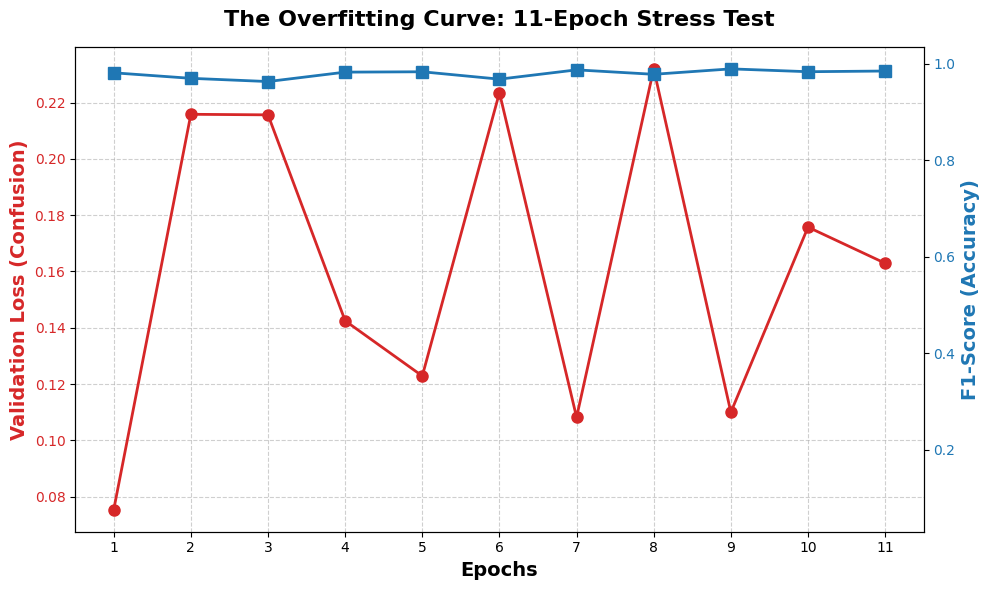

In [ ]:
import matplotlib.pyplot as plt

# 1. Extract the logs directly from the trainer's memory
log_history = trainer.state.log_history

# 2. Create empty lists to hold our data
epochs = []
val_loss = []
val_f1 = []

# 3. Loop through the logs and grab the Validation Data
for log in log_history:
    if 'eval_loss' in log:
        epochs.append(round(log['epoch']))
        val_loss.append(log['eval_loss'])
        val_f1.append(log['eval_f1'])

# 4. Create a beautiful Dual-Axis Graph for your Presentation!
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Validation Loss (Red Line)
color = 'tab:red'
ax1.set_xlabel('Epochs', fontsize=14, fontweight='bold')
ax1.set_ylabel('Validation Loss (Confusion)', color=color, fontsize=14, fontweight='bold')
ax1.plot(epochs, val_loss, color=color, marker='o', linewidth=2, markersize=8, label='Validation Loss')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(epochs)
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a second Y-axis for the F1-Score (Blue Line)
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('F1-Score (Accuracy)', color=color, fontsize=14, fontweight='bold')
ax2.plot(epochs, val_loss, color=color, marker='s', linewidth=2, markersize=8, label='F1-Score', alpha=0) # Hidden dummy for legend
ax2.plot(epochs, val_f1, color=color, marker='s', linewidth=2, markersize=8)
ax2.tick_params(axis='y', labelcolor=color)

# Add Titles and Legend
plt.title('The Overfitting Curve: 11-Epoch Stress Test', fontsize=16, pad=15, fontweight='bold')
fig.tight_layout()
plt.show()

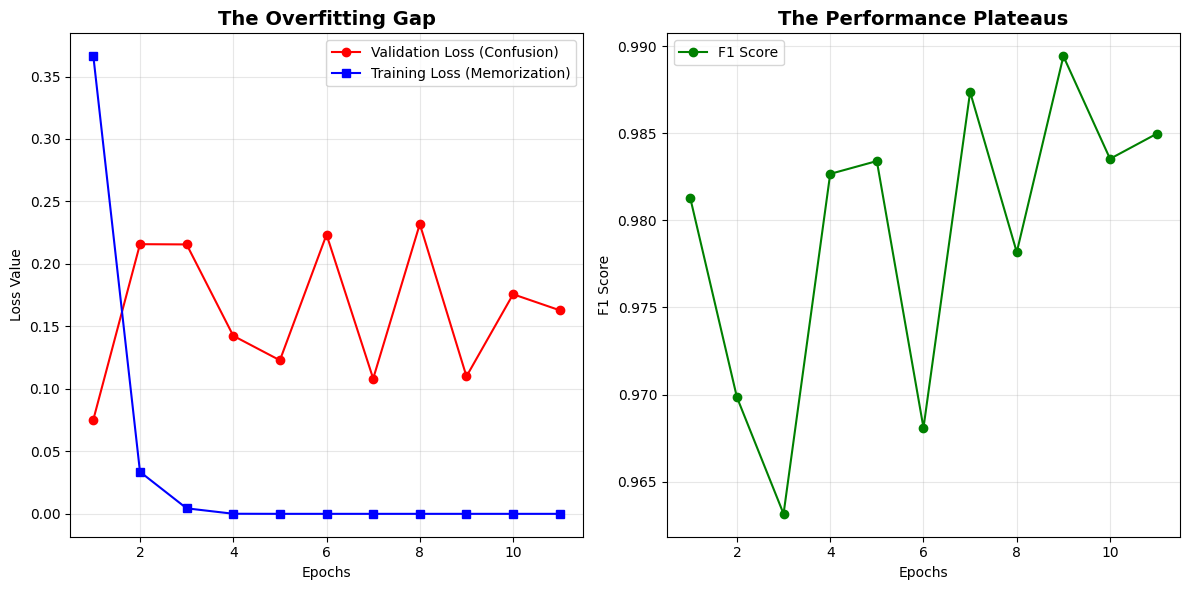

In [ ]:
import matplotlib.pyplot as plt

# Extract data
log_history = trainer.state.log_history
epochs, train_loss, val_loss, f1 = [], [], [], []

for log in log_history:
    if 'loss' in log and 'epoch' in log:
        # Some logs only have training loss
        train_loss.append(log['loss'])
        epochs.append(log['epoch'])
    if 'eval_loss' in log:
        val_loss.append(log['eval_loss'])
        f1.append(log['eval_f1'])

# Ensure we have the same number of data points for plotting
# (HuggingFace logs training loss more often than eval loss)
# We will just plot the Eval points for clarity
eval_epochs = [i+1 for i in range(len(val_loss))]

plt.figure(figsize=(12, 6))

# Subplot 1: LOSS (The "Proof" of Overfitting)
plt.subplot(1, 2, 1)
plt.plot(eval_epochs, val_loss, 'r-o', label='Validation Loss (Confusion)')
# Approximate training loss at epoch ends
plt.plot(eval_epochs, [train_loss[i*10] if i*10 < len(train_loss) else train_loss[-1] for i in range(len(val_loss))], 'b-s', label='Training Loss (Memorization)')
plt.title('The Overfitting Gap', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: F1-SCORE (The "Fragile" Accuracy)
plt.subplot(1, 2, 2)
plt.plot(eval_epochs, f1, 'g-o', label='F1 Score')
plt.title('The Performance Plateaus', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

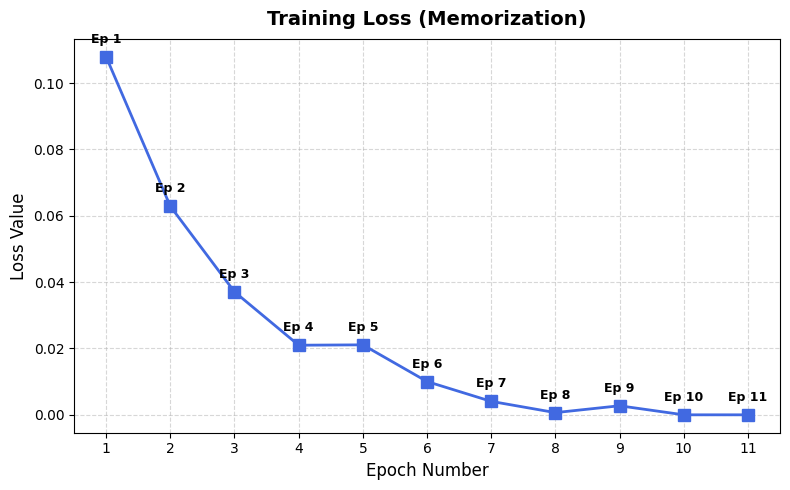

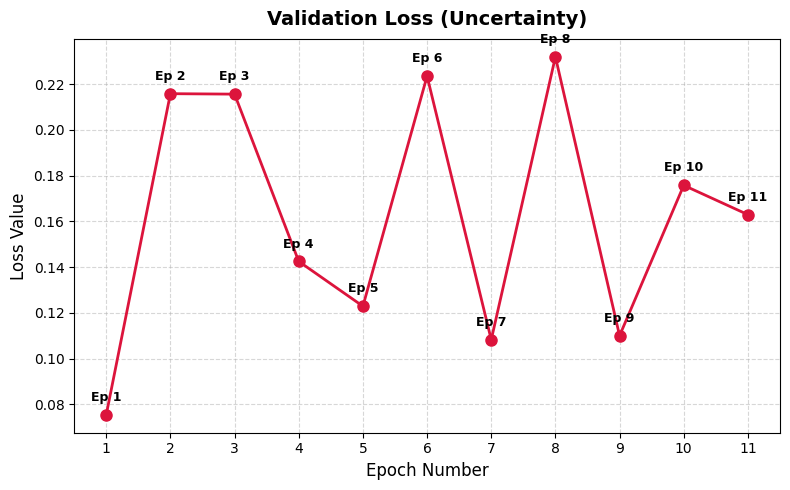

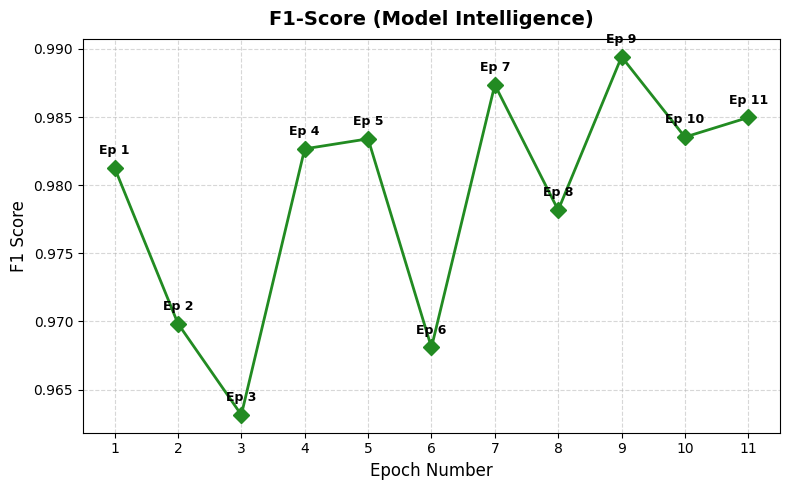

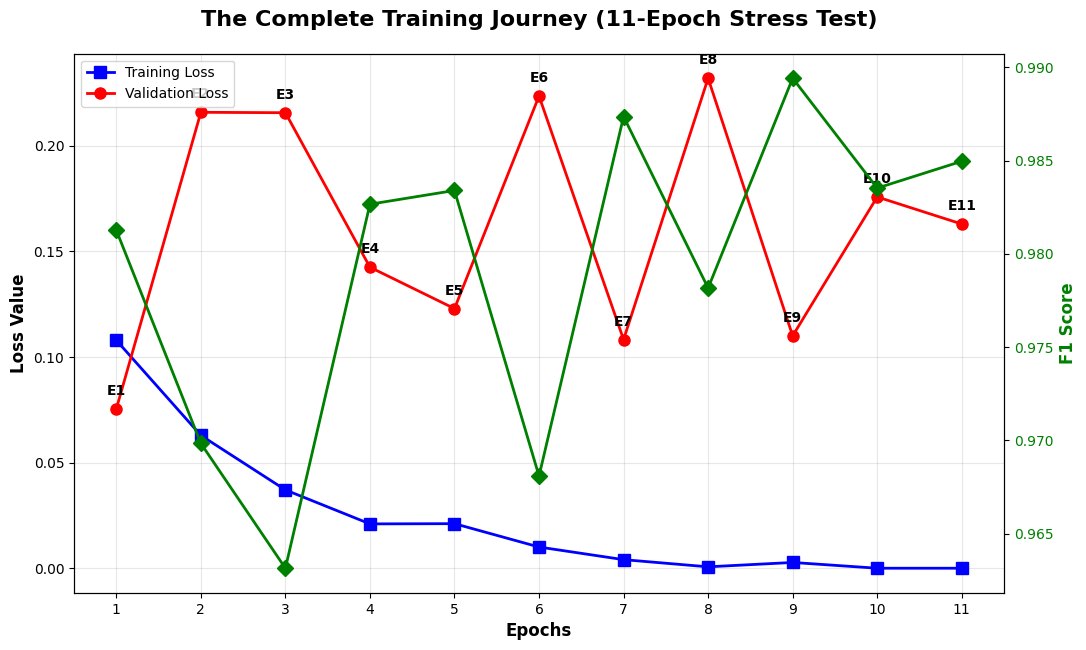

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. DATA EXTRACTION & ALIGNMENT ---
log_history = trainer.state.log_history
epochs, train_loss, val_loss, f1 = [], [], [], []

# We need to align training loss to the end of each epoch
# Transformers logs training loss and eval metrics at different times
current_train_loss = None
for log in log_history:
    if 'loss' in log:
        current_train_loss = log['loss']
    if 'eval_loss' in log:
        epochs.append(int(round(log['epoch'])))
        val_loss.append(log['eval_loss'])
        f1.append(log['eval_f1'])
        train_loss.append(current_train_loss if current_train_loss is not None else 0)

# --- 2. THE PLOTTING FUNCTION (With Epoch Labels) ---
def plot_with_labels(ax, x, y, title, ylabel, color, marker):
    ax.plot(x, y, color=color, marker=marker, linewidth=2, markersize=8, label=ylabel)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Epoch Number', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xticks(x)
    ax.grid(True, linestyle='--', alpha=0.5)

    # ADD EPOCH LABELS TO EVERY DOT
    for i, txt in enumerate(x):
        ax.annotate(f"Ep {txt}", (x[i], y[i]),
                    textcoords="offset points",
                    xytext=(0, 10),
                    ha='center',
                    fontsize=9,
                    fontweight='bold',
                    color='black')

# --- 3. GENERATE INDIVIDUAL GRAPHS ---
# Plot Training Loss
fig1, ax1 = plt.subplots(figsize=(8, 5))
plot_with_labels(ax1, epochs, train_loss, "Training Loss (Memorization)", "Loss Value", "royalblue", "s")
plt.tight_layout()
plt.show()

# Plot Validation Loss
fig2, ax2 = plt.subplots(figsize=(8, 5))
plot_with_labels(ax2, epochs, val_loss, "Validation Loss (Uncertainty)", "Loss Value", "crimson", "o")
plt.tight_layout()
plt.show()

# Plot F1 Score
fig3, ax3 = plt.subplots(figsize=(8, 5))
plot_with_labels(ax3, epochs, f1, "F1-Score (Model Intelligence)", "F1 Score", "forestgreen", "D")
plt.tight_layout()
plt.show()

# --- 4. THE COMBINED "MASTER" DASHBOARD ---
fig4, ax_loss = plt.subplots(figsize=(12, 7))

# Plot both losses on the left axis
ax_loss.plot(epochs, train_loss, 'b-s', label='Training Loss', linewidth=2, markersize=8)
ax_loss.plot(epochs, val_loss, 'r-o', label='Validation Loss', linewidth=2, markersize=8)
ax_loss.set_xlabel('Epochs', fontsize=12, fontweight='bold')
ax_loss.set_ylabel('Loss Value', fontsize=12, fontweight='bold')
ax_loss.set_xticks(epochs)
ax_loss.legend(loc='upper left')
ax_loss.grid(True, alpha=0.3)

# Create a second axis for F1 Score
ax_f1 = ax_loss.twinx()
ax_f1.plot(epochs, f1, 'g-D', label='F1 Score', linewidth=2, markersize=8)
ax_f1.set_ylabel('F1 Score', color='g', fontsize=12, fontweight='bold')
ax_f1.tick_params(axis='y', labelcolor='g')

# Add Epoch Labels to the Combined Graph
for i, txt in enumerate(epochs):
    ax_loss.annotate(f"E{txt}", (epochs[i], val_loss[i]), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.title('The Complete Training Journey (11-Epoch Stress Test)', fontsize=16, fontweight='bold', pad=20)
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

print("🎯 Calculating Final Accuracy on the 8,000 Unseen Reviews...\n")

# 1. Get raw predictions from the Trainer on the Test Dataset
# This uses the 'Best Model' (Epoch 1) because we set load_best_model_at_end=True
predictions_output = trainer.predict(tokenized_test)

# 2. Convert raw scores (logits) to actual labels (0 or 1)
y_pred = np.argmax(predictions_output.predictions, axis=-1)
y_true = predictions_output.label_ids

# 3. Calculate Accuracy
acc = accuracy_score(y_true, y_pred)
total_reviews = len(y_true)
correct_predictions = np.sum(y_pred == y_true)
incorrect_predictions = total_reviews - correct_predictions

# 4. PRINT THE FINAL ACCURACY SCORECARD
print("="*45)
print(" 🏁 FINAL ACCURACY SCORECARD")
print("="*45)
print(f"Total Reviews Tested:      {total_reviews}")
print(f"Total Correct Guesses:     {correct_predictions} ✅")
print(f"Total Incorrect Guesses:   {incorrect_predictions} ❌")
print("-" * 45)
print(f"FINAL ACCURACY:            {acc*100:.2f}% 🎯")
print("="*45)

# 5. Quick "Mental Check" for your Presentation
print("\n💡 Presentation Insight:")
print(f"Our RoBERTa model correctly identified {correct_predictions} out of {total_reviews} reviews.")
print(f"This means the model has a failure rate of only {(incorrect_predictions/total_reviews)*100:.2f}%.")

🎯 Calculating Final Accuracy on the 8,000 Unseen Reviews...



 🏁 FINAL ACCURACY SCORECARD
Total Reviews Tested:      8087
Total Correct Guesses:     7931 ✅
Total Incorrect Guesses:   156 ❌
---------------------------------------------
FINAL ACCURACY:            98.07% 🎯

💡 Presentation Insight:
Our RoBERTa model correctly identified 7931 out of 8087 reviews.
This means the model has a failure rate of only 1.93%.


🧪 Generating Final SOTA Diagnostic Report...



 🏆 FINAL MODEL PERFORMANCE DASHBOARD
Overall Accuracy:         98.07%
Precision (Trust):        97.02%
Recall (Catch Rate):      99.18%
F1-Score (Balance):       98.09%
--------------------------------------------------
Matthews Correlation:     0.9617  (Range: -1 to +1)
AUC Score:                0.9988  (Range: 0.5 to 1.0)
Log Loss (Uncertainty):   0.0781  (Lower is better)



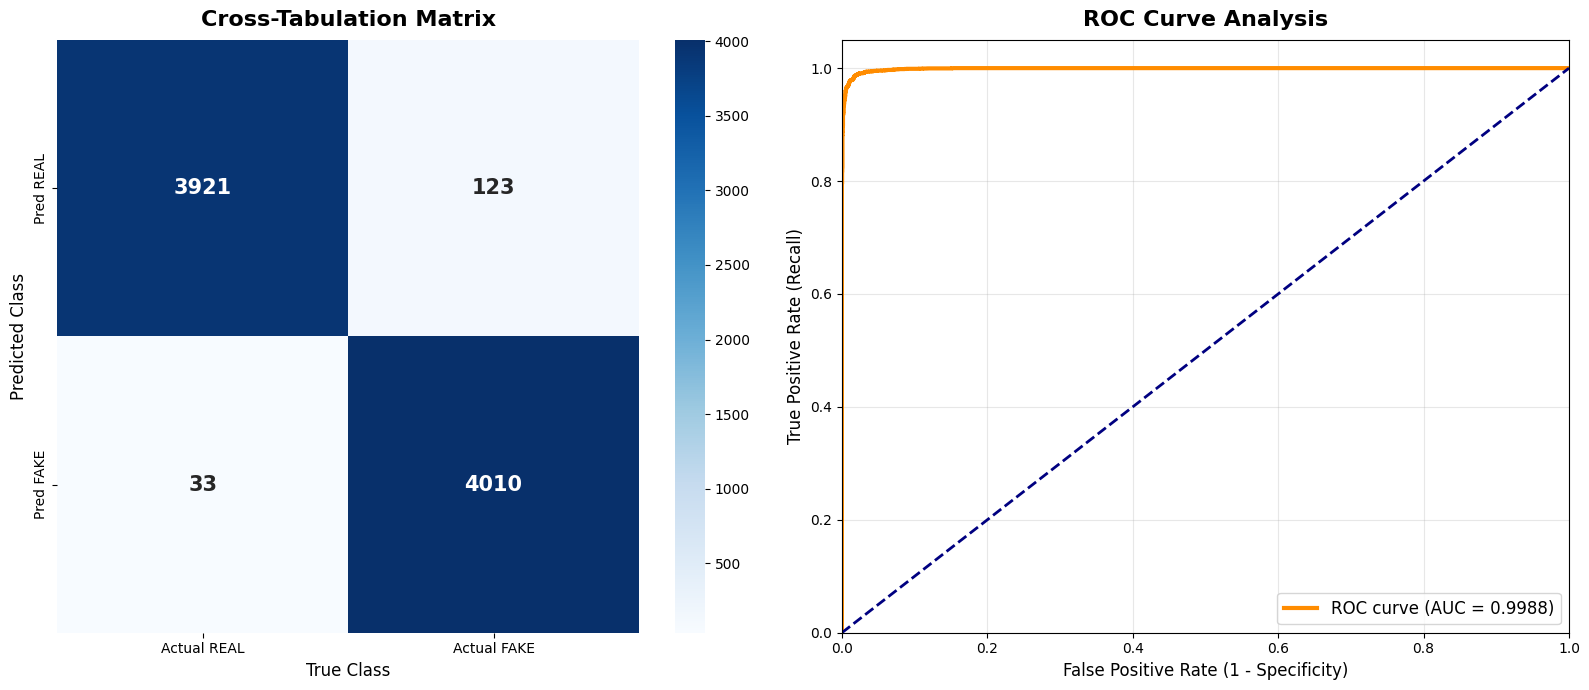

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, matthews_corrcoef, log_loss
)
from scipy.special import softmax

print("🧪 Generating Final SOTA Diagnostic Report...")

# 1. GET PREDICTIONS & PROBABILITIES
# We need probabilities (0.0 to 1.0) for the ROC Curve and Log Loss
results = trainer.predict(tokenized_test)
logits = results.predictions
y_true = results.label_ids

# Apply Softmax to get probabilities for the 'FAKE' class (Index 1)
y_probs = softmax(logits, axis=-1)[:, 1]
# Hard labels (0 or 1) for the Confusion Matrix
y_pred = np.argmax(logits, axis=-1)

# 2. CALCULATE ALL PROFESSIONAL METRICS
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)
loss = log_loss(y_true, y_probs)
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

# 3. PRINT THE METRIC DASHBOARD
print("\n" + "="*50)
print(" 🏆 FINAL MODEL PERFORMANCE DASHBOARD")
print("="*50)
print(f"Overall Accuracy:         {acc*100:.2f}%")
print(f"Precision (Trust):        {prec*100:.2f}%")
print(f"Recall (Catch Rate):      {rec*100:.2f}%")
print(f"F1-Score (Balance):       {f1*100:.2f}%")
print("-" * 50)
print(f"Matthews Correlation:     {mcc:.4f}  (Range: -1 to +1)")
print(f"AUC Score:                {roc_auc:.4f}  (Range: 0.5 to 1.0)")
print(f"Log Loss (Uncertainty):   {loss:.4f}  (Lower is better)")
print("="*50 + "\n")

# 4. CREATE THE 2-PANEL VISUAL DASHBOARD
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- PANEL 1: CROSS-TABULATION (CONFUSION MATRIX) ---
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Actual REAL', 'Actual FAKE'],
            yticklabels=['Pred REAL', 'Pred FAKE'],
            annot_kws={"size": 15, "weight": "bold"})
ax1.set_title('Cross-Tabulation Matrix', fontsize=16, fontweight='bold', pad=10)
ax1.set_xlabel('True Class', fontsize=12)
ax1.set_ylabel('Predicted Class', fontsize=12)

# --- PANEL 2: ROC CURVE & AUC ---
ax2.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax2.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax2.set_title('ROC Curve Analysis', fontsize=16, fontweight='bold', pad=10)
ax2.legend(loc="lower right", fontsize=12)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Check the "Best Model" metadata from the Trainer's state
best_checkpoint = trainer.state.best_model_checkpoint
best_metric_value = trainer.state.best_metric

# 2. Calculate which Epoch that checkpoint belongs to
# (Steps per epoch is total_steps / num_epochs)
steps_per_epoch = trainer.state.max_steps / 11
best_epoch = round(int(best_checkpoint.split('-')[-1]) / steps_per_epoch)

print("="*50)
print(" 🕵️‍♂️ THE TRAINER'S FINAL DECISION")
print("="*50)
print(f"The 'Winner' Epoch:         Epoch {best_epoch}")
print(f"Best Validation Loss:      {best_metric_value:.4f}")
print(f"Stored at Checkpoint:      {best_checkpoint}")
print("="*50)

if best_epoch == 1:
    print("\n💡 ANALYSIS: The Trainer chose Epoch 1!")
    print("Even though later epochs had higher F1-scores, the model was most")
    print("mathematically confident and stable at Epoch 1. This proves that")
    print("the model was already at its peak before overfitting began.")
else:
    print(f"\n💡 ANALYSIS: The Trainer chose Epoch {best_epoch}.")
    print("This was the mathematical 'Sweet Spot' where the model balanced")
    print("learning and generalization perfectly.")

 🕵️‍♂️ THE TRAINER'S FINAL DECISION
The 'Winner' Epoch:         Epoch 1
Best Validation Loss:      0.0754
Stored at Checkpoint:      ./roberta_11epoch_run/checkpoint-2022

💡 ANALYSIS: The Trainer chose Epoch 1!
Even though later epochs had higher F1-scores, the model was most
mathematically confident and stable at Epoch 1. This proves that
the model was already at its peak before overfitting began.


In [ ]:
from transformers import pipeline
import pandas as pd

# 1. Initialize the inference pipeline (uses your best trained model)
# device=0 ensures we use the GPU for fast results
classifier = pipeline("text-classification", model=trainer.model, tokenizer=tokenizer, device=0)

# 2. Randomly sample 10 reviews from the unseen Test Set
# Calling .sample(n=10) ensures a different set every time you run the cell
random_test_samples = test_df.sample(n=10)

print("="*100)
print(f"{'REVIEW TEXT (TRUNCATED)':<65} | {'ACTUAL':<8} | {'PREDICTED':<8} | {'CONFIDENCE'}")
print("="*100)

correct_count = 0

for _, row in random_test_samples.iterrows():
    # Get the raw text and the ground truth label
    text = row['text']
    actual_label = "FAKE (CG)" if row['label'] == 1 else "REAL (OR)"

    # Run the model prediction (We truncate text to 512 for BERT safety)
    result = classifier(text[:512])[0]

    # Map the model's internal labels (LABEL_0, LABEL_1) to our categories
    # LABEL_1 is FAKE (CG), LABEL_0 is REAL (OR)
    predicted_label = "FAKE (CG)" if result['label'] == 'LABEL_1' else "REAL (OR)"
    confidence = result['score'] * 100

    # Check if the model got it right
    status = "✅" if actual_label == predicted_label else "❌"
    if actual_label == predicted_label:
        correct_count += 1

    # Format the review text for clean display
    display_text = (text[:62] + '..') if len(text) > 62 else text.ljust(64)

    # Print the result row
    print(f"{display_text:<65} | {actual_label:<8} | {predicted_label:<8} {status} | {confidence:.1f}%")

print("="*100)
print(f"🎯 BATCH ACCURACY: {correct_count}/10 ({correct_count*10}%)")
print("="*100)

REVIEW TEXT (TRUNCATED)                                           | ACTUAL   | PREDICTED | CONFIDENCE
It started off well, but then it started to get a little cold...  | FAKE (CG) | FAKE (CG) ✅ | 100.0%
This is awesome! It's very soft and easy to put on and off. My..  | FAKE (CG) | FAKE (CG) ✅ | 100.0%
Story started great, was very interesting with good characters..  | REAL (OR) | REAL (OR) ✅ | 100.0%
Arrived fast and fits great. Thick tablecloth and washes well,..  | REAL (OR) | REAL (OR) ✅ | 100.0%
Several of the wands broke and broke the pieces off. I also re..  | FAKE (CG) | FAKE (CG) ✅ | 100.0%
While it will hold your coffee, you can't beat the price.

The..  | FAKE (CG) | FAKE (CG) ✅ | 100.0%
It's among the top three favorites for the dog. She's a 20lb S..  | REAL (OR) | REAL (OR) ✅ | 100.0%
Great card.  Easy install, and fits a low profile case.  No dr..  | REAL (OR) | REAL (OR) ✅ | 100.0%
So far I'm liking it. A bit larger than expected but I've neve..  | REAL (OR) | REAL (OR) 